In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [61]:
data = pd.read_csv("../data/titanic.csv")
data.head(10)

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0
5,1,27.0,0,8.4583,0,0,1,0
6,1,54.0,0,51.8625,1,0,0,0
7,1,2.0,4,21.0750,0,0,1,0
8,0,27.0,2,11.1333,0,0,1,1
9,0,14.0,1,30.0708,0,1,0,1


In [62]:
print("--- Dataset Info ---")
data.info()

print("\n--- Descriptive Statistics ---")
data.describe()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB

--- Descriptive Statistics ---


,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


In [50]:
print("--- Missing Values Count ---")
print(data.isna().sum())

--- Missing Values Count ---
sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
class          0
dtype: int64


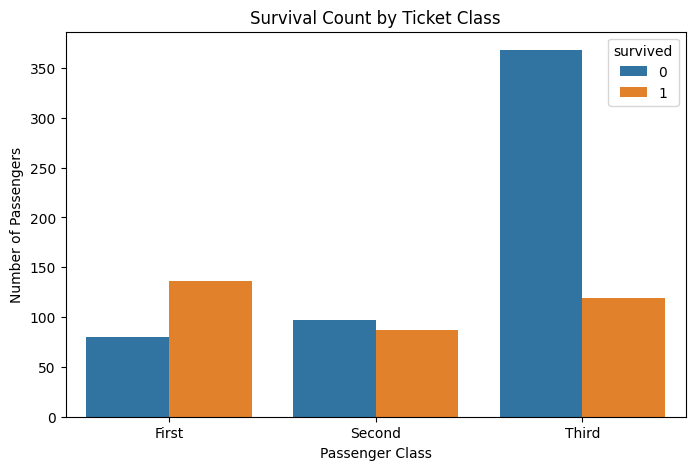

In [51]:
class_data = []
for index, row in data.iterrows():
    if row['1st_class'] == 1:
        class_data.append('First')
    elif row['2nd_class'] == 1:
        class_data.append('Second')
    else:
        class_data.append('Third')

data['Class_Group'] = class_data

# Plot the relationship
plt.figure(figsize=(8, 5))
sns.countplot(x='Class_Group', hue='survived', data=data, order=['First', 'Second', 'Third'])
plt.title('Survival Count by Ticket Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

#------------------------------------------------------------------------------------------------------------------------------

In [76]:
print(data['sex'].unique())
print(data['sex'].value_counts())
print(data['sex'].nunique())
print(data['family_size'].unique())
print(data['1st_class'].unique())
print(data['2nd_class'].unique())
print(data['3rd_class'].unique())
print(data['survived'].unique())

[1 0]
sex
1    573
0    314
Name: count, dtype: int64
2
[ 1  0  4  2  6  5  3  7 10]
[0 1]
[0 1]
[1 0]
[0 1]


In [80]:
high_fare_passengers = data[(data['fare'] > 40) & (data['survived'] == 1) & (data['3rd_class'] == 1)]
high_fare_passengers.head(20)

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
73,1,32.0,0,56.4958,0,0,1,1
506,1,26.0,0,56.4958,0,0,1,1
640,1,32.0,0,56.4958,0,0,1,1
689,1,37.0,0,56.4958,0,0,1,1
834,1,32.0,0,56.4958,0,0,1,1


In [ ]:
high_fare_passengers = data[(data['fare'] > 40) & (data['survived'] == 1) & (data['3rd_class'] == 1)]
high_fare_passengers.head(20)

In [84]:
# 1. Select just the class columns and sum them horizontally (axis=1)
class_sums = data[['1st_class', '2nd_class', '3rd_class']].sum(axis=1)

# 2. Filter for rows where the sum is greater than 1
corrupted_classes = data[class_sums > 1]

print(f"Number of passengers with 2 or more classes assigned: {len(corrupted_classes)}")
# Display the bad records
corrupted_classes[['1st_class', '2nd_class', '3rd_class']]

Number of passengers with 2 or more classes assigned: 0


,1st_class,2nd_class,3rd_class


In [83]:
ghost_passengers = data[class_sums == 0]
print(f"Number of passengers with zero classes assigned: {len(ghost_passengers)}")

Number of passengers with zero classes assigned: 0


In [59]:
high_fare_or_survived = data[(data['fare'] > 150) & (data['survived'] == 1)]
high_fare_or_survived.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
87,0,23.00,5,263.0000,1,0,0,1
257,0,35.00,0,512.3292,1,0,0,1
266,0,58.00,1,153.4625,1,0,0,1
297,0,50.00,1,247.5208,1,0,0,1
303,1,0.92,3,151.5500,1,0,0,1


In [64]:
family_with_zero_members = data[data['family_size'] == 0]
family_with_zero_members.head(10)

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
2,0,26.0,0,7.9250,0,0,1,1
4,1,35.0,0,8.0500,0,0,1,0
5,1,27.0,0,8.4583,0,0,1,0
6,1,54.0,0,51.8625,1,0,0,0
11,0,58.0,0,26.5500,1,0,0,1
12,1,20.0,0,8.0500,0,0,1,0
14,0,14.0,0,7.8542,0,0,1,0
15,0,55.0,0,16.0000,0,1,0,1
17,1,23.0,0,13.0000,0,1,0,1
19,0,22.0,0,7.2250,0,0,1,1


In [69]:
valid_ages = data[data['age'] < 2]
valid_ages.head(10)

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
77,1,0.83,2,29.0000,0,1,0,1
163,1,1.00,5,39.6875,0,0,1,0
171,0,1.00,2,11.1333,0,0,1,1
182,1,1.00,3,39.0000,0,1,0,1
303,1,0.92,3,151.5500,1,0,0,1
379,0,1.00,2,15.7417,0,0,1,1
384,1,1.00,7,46.9000,0,0,1,0
466,0,0.75,3,19.2583,0,0,1,1
641,0,0.75,3,19.2583,0,0,1,1
751,1,0.67,2,14.5000,0,1,0,1


In [ ]:
high_fare_passengers = data[data['family_size'] > 1]
high_fare_passengers.head()

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


In [13]:
data.isna().sum()

sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64

In [23]:
data.duplicated().sum()

np.int64(70)

In [11]:
data.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='sex', ylabel='count'>

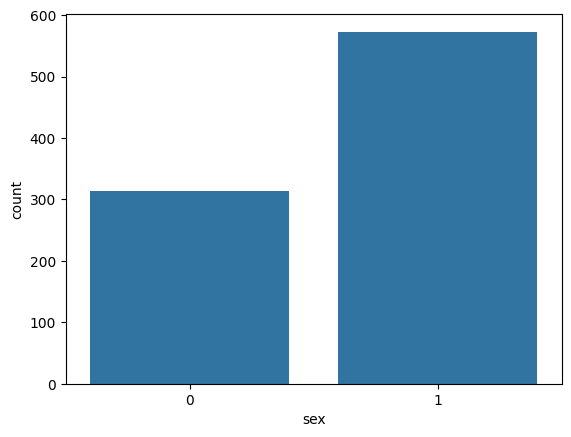

In [46]:
sns.countplot(x='sex', data=data)

<Axes: xlabel='survived', ylabel='count'>

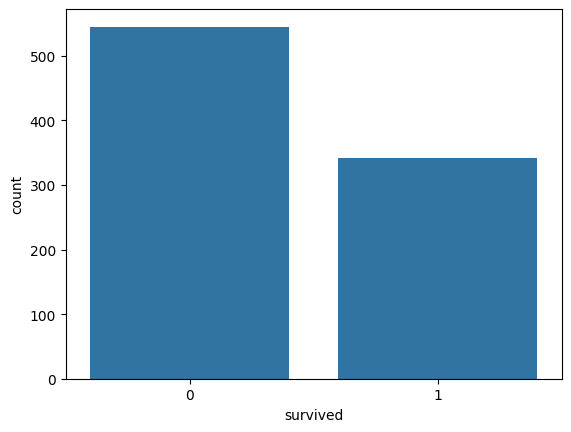

In [16]:
sns.countplot(x='survived', data=data)

<Axes: xlabel='survived', ylabel='count'>

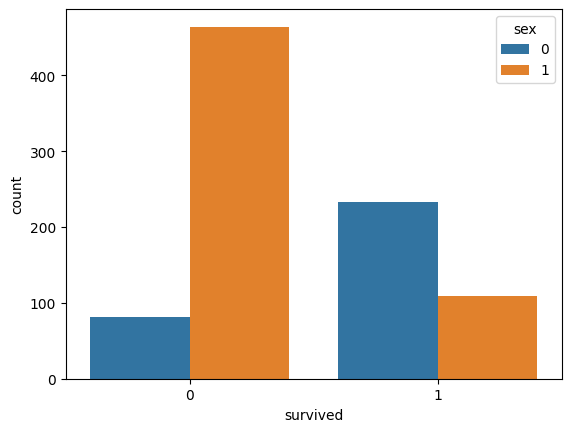

In [18]:
sns.countplot(x='survived', hue='sex', data=data)

<Axes: xlabel='sex', ylabel='survived'>

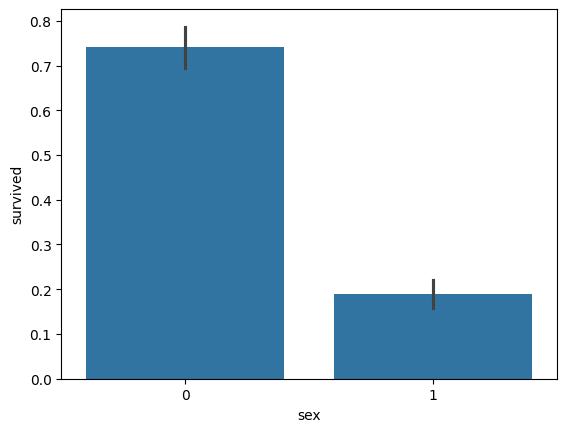

In [17]:
sns.barplot(x='sex', y='survived', data=data)

<Axes: xlabel='class', ylabel='survived'>

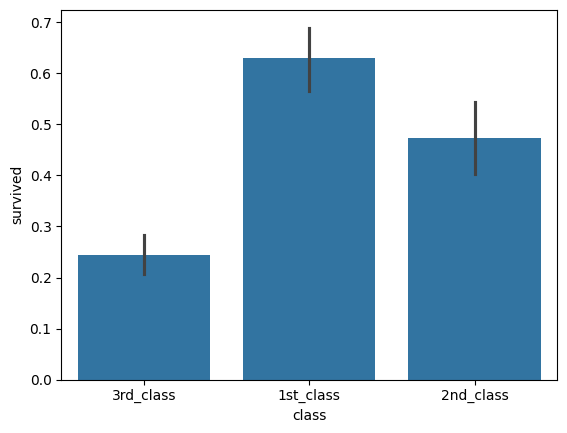

In [19]:
data['class'] = data[['1st_class','2nd_class','3rd_class']].idxmax(axis=1)
sns.barplot(x='class', y='survived', data=data)

In [21]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

ValueError: could not convert string to float: '3rd_class'

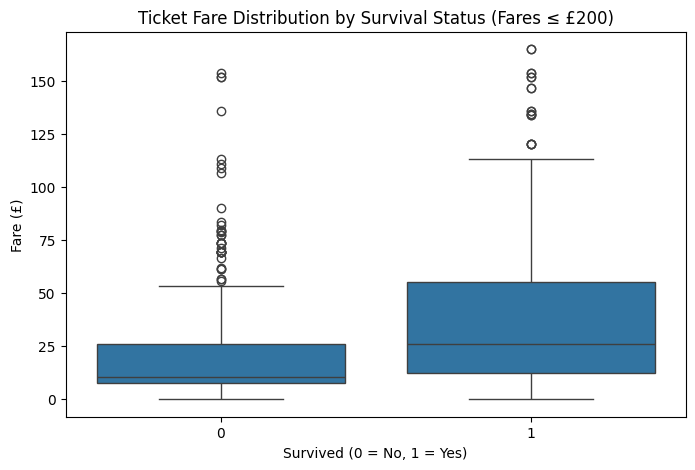

In [42]:
filtered_data = data[data['fare'] <= 200]

# 2. Create the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='survived', y='fare', data=filtered_data)

# 3. Make it readable
plt.title('Ticket Fare Distribution by Survival Status (Fares ≤ £200)')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare (£)')
plt.show()

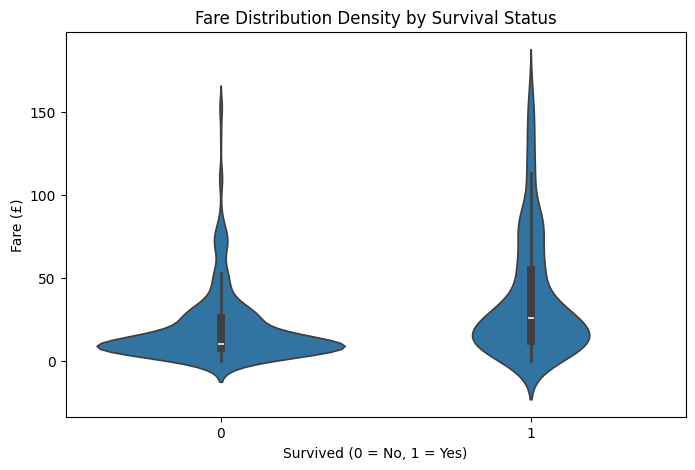

In [43]:
plt.figure(figsize=(8, 5))

# Create the violin plot using the filtered data
sns.violinplot(x='survived', y='fare', data=filtered_data)

plt.title('Fare Distribution Density by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare (£)')
plt.show()

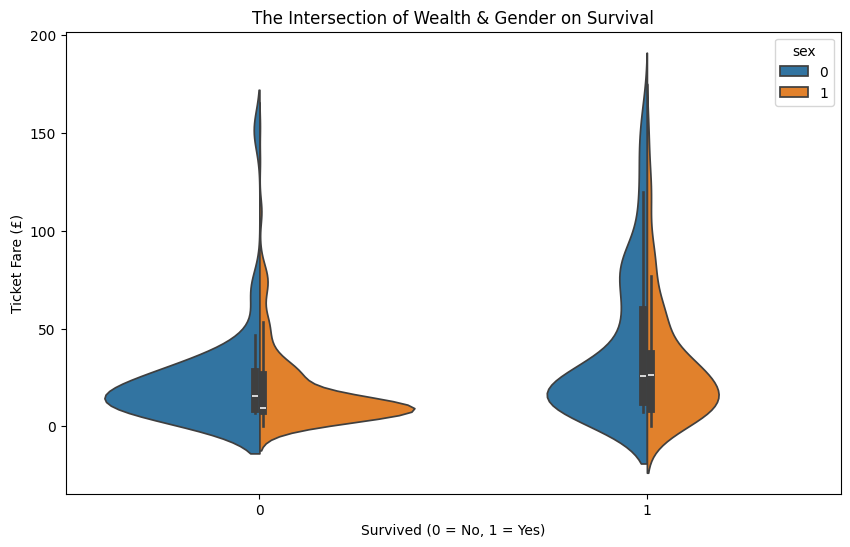

In [44]:
plt.figure(figsize=(10, 6))

# split=True merges the male/female data into a single violin per survival category
sns.violinplot(x='survived', y='fare', hue='sex', data=filtered_data, split=True)

plt.title('The Intersection of Wealth & Gender on Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()

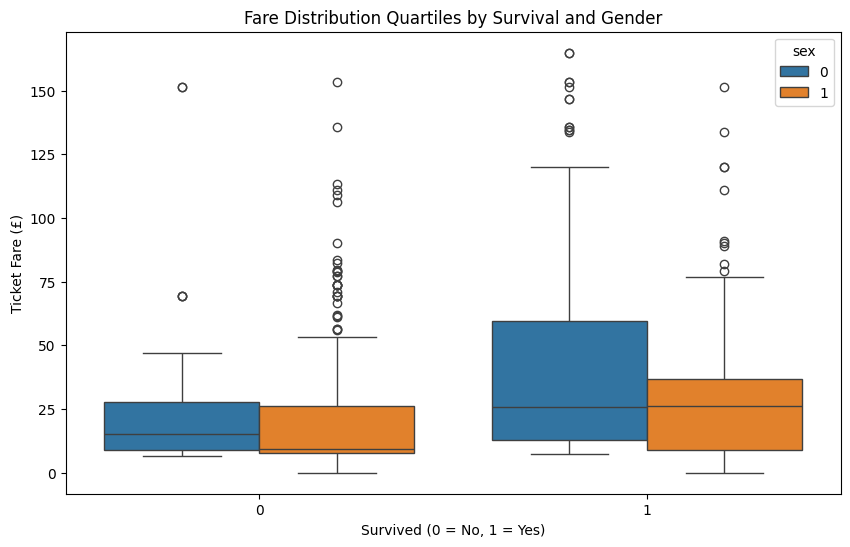

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='survived', y='fare', hue='sex', data=filtered_data)

plt.title('Fare Distribution Quartiles by Survival and Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()

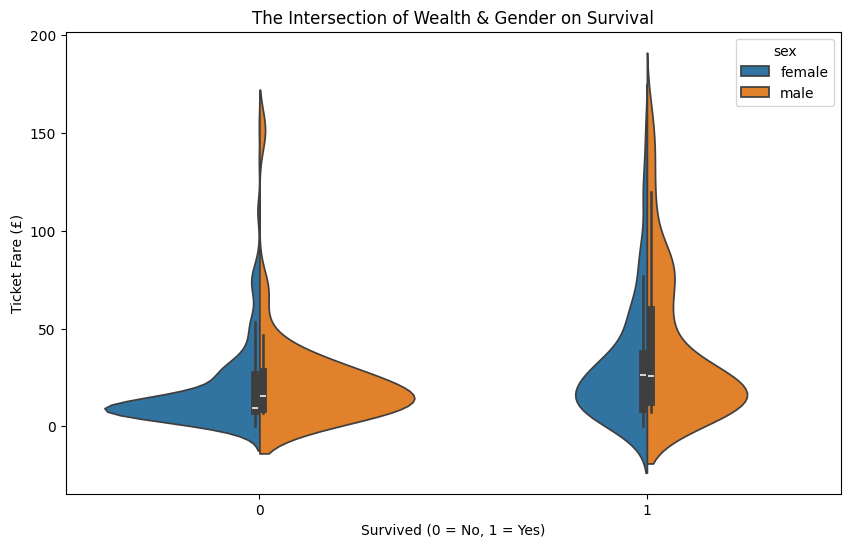

In [45]:
# Create a copy to avoid modifying your original data
plot_data = filtered_data.copy()

# Map the numeric codes back to readable categories
# (Assuming 0 is male and 1 is female based on Titanic data distributions)
plot_data['sex'] = plot_data['sex'].map({0: 'male', 1: 'female'})

# Re-run your plot code using the updated dataframe
plt.figure(figsize=(10, 6))
sns.violinplot(x='survived', y='fare', hue='sex', data=plot_data, split=True)

plt.title('The Intersection of Wealth & Gender on Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (£)')
plt.show()